In [14]:
!pip install scikit-learn

Defaulting to user installation because normal site-packages is not writeable
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 97.3 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3/3 [scikit-learn] [scikit-learn]


In [1]:
# make sure we are in the right folder to begin working
import os

target_folder = "CS6423_knowledge_distillation_project" 
path = os.path.join(os.getcwd(), target_folder)

if os.path.exists(path):
    os.chdir(path)

# should match the folder you cloned into
print(f"Current working directory: {os.getcwd()}")

Current working directory: /home/epoc2/CS6423_knowledge_distillation_project


### Loading the pretrained model
Function that loads weights and returns fully trained model - our teacher - as pre_model

In [2]:
import torch
import torch.nn as nn
from torchvision import models
import argparse
from collections import OrderedDict
from torchsummary import summary

# define function to initialize and return our pretrained model - the resnet50
def load_pre_model(checkpoint_path, device):
    pre_model = models.resnet50(weights=None)
    pre_model.fc = nn.Linear(2048, 165)
    fc_num_ftrs = pre_model.fc.in_features

    torch.serialization.add_safe_globals([argparse.Namespace])
    checkpoint = torch.load(checkpoint_path, map_location='cpu', weights_only=False)

    state_dict = checkpoint['model']
    new_state_dict = OrderedDict()
    for k, v in state_dict.items():
        name = k.replace('_orig_mod.', '') 
        new_state_dict[name] = v

    pre_model.load_state_dict(new_state_dict, strict=True)
    
    pre_model.eval()
    for p in pre_model.parameters():
        p.requires_grad = False

    # send to gpu and output summary
    pre_model.to(device)
    # summary(pre_model, input_size=(3, 224, 224))
    return pre_model


Function for saving our supernet model as we train it

In [3]:
# define a function to save our supernet model
def save_supernet(model, path="supernet_checkpoint.pth"):
    # we'll save the state dict along with the search space for future reference
    torch.save({
        'state_dict': model.state_dict(),
        'width_mult_list': [0.65, 0.8, 1.0, 1.2],
        'search_space': {
            'res': [128, 160, 190, 224],
            'depth': [2, 3, 4],
            'exp': [3, 4, 6]
        }
    }, path)
    print(f"supernet saved to {path}")

### Preparing Data Loaders
We need to provide data loaders to our training function.  We need:
* training loader - used to distill knowledge into supernet
* search/validation loader - used by the genetic algorithm later to calculate accuracy without any bias
* test loader - final test set to verify performance of student model

Here we'll initialize them.

In [4]:
from torch.utils.data import DataLoader, Subset, random_split
from torchvision import datasets, transforms

# fiachra's transform functions from modules data prepepr
def get_train_transform(self):
    return transforms.Compose(
        [
            transforms.Resize(256),
            transforms.RandomRotation(15),
            transforms.RandomHorizontalFlip(),
            transforms.RandomResizedCrop(224, scale=(0.8, 1.0)),
            transforms.ColorJitter(brightness=0.2, contrast=0.2),
            transforms.ToTensor(),
        ]
    )

def get_val_transform(self):
    return transforms.Compose(
        [
            transforms.Resize(256),
            transforms.CenterCrop(224),
            transforms.ToTensor(),
        ]
    )


def get_data_loaders(data_dir, batch_size=32):
    # transforms - ought to match those applied to our dta during resnet fine-tuning
    train_transform = transforms.Compose([
        transforms.Grayscale(num_output_channels=1),
        transforms.Resize((224, 224)),
        transforms.RandomHorizontalFlip(),
        transforms.RandomRotation(10),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.5], std=[0.5])
    ])

    val_test_transform = transforms.Compose([
        transforms.Grayscale(num_output_channels=1),
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.5], std=[0.5])
    ])

    # load actual dataset
    full_dataset = datasets.ImageFolder(data_dir)
   
    # perform split
    train_size = int(0.8 * len(full_dataset))
    search_size = int(0.1 * len(full_dataset))
    test_size = len(full_dataset) - train_size - search_size
   
    train_data, search_data, test_data = random_split(
        full_dataset, [train_size, search_size, test_size]
    )

    # apply transforms
    train_data.dataset.transform = get_train_transforms
    search_data.dataset.transform = get_val_transforms
    test_data.dataset.transform = get_val_transforms

    # create loaders and return
    train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True, num_workers=4)
    search_loader = DataLoader(search_data, batch_size=batch_size, shuffle=False)
    test_loader = DataLoader(test_data, batch_size=batch_size, shuffle=False)
    return train_loader, search_loader, test_loader


In [4]:
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from sklearn.model_selection import train_test_split
from torchvision import transforms
import pandas as pd
from PIL import Image

df = pd.read_csv('data/labels.csv')

train_transforms = transforms.Compose([
    transforms.Resize(256),
    transforms.RandomRotation(15),
    transforms.RandomHorizontalFlip(),
    transforms.RandomResizedCrop(224, scale=(0.8, 1.0)),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
])

val_transforms = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
])

class RadiologyDataset(Dataset):
    def __init__(self, dataframe: pd.DataFrame, image_dir, transform=None):
        self.df = dataframe
        self.image_dir = image_dir
        self.transform = transform
        
        # map string labels to numbers (0-121)
        self.labels = self.df['label'].astype('category').cat.codes.values
        self.class_names = self.df['label'].astype('category').cat.categories

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        img_path = os.path.join(self.image_dir, self.df.iloc[idx]['filename'])
        image = Image.open(img_path).convert('RGB')
        label = torch.tensor(self.labels[idx], dtype=torch.long)
        
        if self.transform:
            image = self.transform(image)
            
        return image, label

train_df, temp_df = train_test_split(
    df,
    test_size=0.2,
    stratify=df['label'],
    random_state=43
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.5,
    stratify=temp_df['label'],
    random_state=42
)

train_set = RadiologyDataset(train_df, image_dir="data/test_images", transform=train_transforms)
val_set = RadiologyDataset(val_df, image_dir="data/test_images", transform=val_transforms)
test_set = RadiologyDataset(test_df, image_dir="data/test_images", transform=val_transforms)

print(len(train_set))
print(len(val_set))
print(len(test_set))

7200
900
900


### Supernet training
Here we pull together the various functions to actually train the supernet model and save it.

In [16]:
''' search space:
input resolution = [128, 160, 190, 224]
depth = [2, 3, 4]
width = [0.65, 0.8, 1.0, 1.2]
expansion ratio = [3,4,6]
'''
from knowledge_distillation.model_init import Supernet
from knowledge_distillation.train_loop import DistillationLoss, sample_configs, train_supernet
import torch.optim as optim
from torch.optim.lr_scheduler import CosineAnnealingLR, SequentialLR, LinearLR

# main function to orchestrate training
def main():
    # define params for loaidng model
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    pretrained_model_checkpoint = 'RadImageNet_weights/resnet50.pth'
    pre_model = load_pre_model(pretrained_model_checkpoint, device)  # call model loading function
    
    # initialize our search space params and our supernet model
    width = [0.65, 0.8, 1.0, 1.2]
    snet = Supernet(width, num_classes=165)
    
    num_params = sum(p.numel() for p in snet.parameters())
    print("Parameters:", num_params)
    print("Estimated FP32 size:", num_params * 4 / 1024**3, "GB")
    
    '''total_params = 0
    for name, param in snet.named_parameters():
        num = param.numel()
        total_params += num
        if num > 1_000_000_000:
            print(f'ISSUE: Layer {name} has {num} parameters, Shape: {param.shape}')'''
    
    snet.to(device)
    # print(Supernet)  # confirm object
    
    # we will run train_supernet(supernet, teacher, paths_sampled, train_loader, optimizer, epoch, warmup_epochs=10)
    # training params
    data_directory = 'data/test_images'
    batch_size = 32
    epochs = 100
    warmup_epochs=15
    paths_sampled=20
    peak_lr = 0.05
    
    # optimizer and LR scheduler
    optimizer = optim.SGD(snet.parameters(), lr=peak_lr, momentum=0.9, weight_decay=4e-5)
    scheduler_warmup = LinearLR(optimizer, start_factor=0.01, end_factor=1.0, total_iters=warmup_epochs) # warmup 0.0005 -> 0.05
    scheduler_cosine = CosineAnnealingLR(optimizer, T_max=(epochs - warmup_epochs), eta_min=1e-4)  # decay 0.05 -> 0.0001
    scheduler = SequentialLR(optimizer, schedulers=[scheduler_warmup, scheduler_cosine],  milestones=[warmup_epochs])
    
    #train_loader, search_loader, test_loader = get_data_loaders(data_directory, batch_size = batch_size)
    train_loader = DataLoader(train_set, batch_size=batch_size, shuffle=True, num_workers=4)
    best_loss = 1.0
    
    for epoch in range(epochs):        
        avg_loss = train_supernet(snet, pre_model, paths_sampled, train_loader, optimizer, epoch, warmup_epochs)
        
        scheduler.step()
        
        # save every 5 epochs if loss is improving
        if (epoch+1)%5 == 0:
            save_supernet(snet, f'supernet_epoch_{epoch+1}.pth')
            print(f'Epoch {epoch+1} | LR {scheduler.get_last_lr()[0]:.6f} | Avg Loss {avg_loss}')

In [17]:
main()    

Parameters: 671000144
Estimated FP32 size: 2.4996703267097473 GB
Epoch 0 | warm | Batch 0: current path loss is 7.2352
Epoch 1 | warm | Batch 0: current path loss is 7.2633
Epoch 2 | warm | Batch 0: current path loss is 7.2257
Epoch 3 | warm | Batch 0: current path loss is 6.9203
Epoch 4 | warm | Batch 0: current path loss is 6.3288
supernet saved to supernet_epoch_5.pth
Epoch 5 | LR 0.017000 | Avg Loss 6.328765869140625
Epoch 5 | warm | Batch 0: current path loss is 7.0188
Epoch 6 | warm | Batch 0: current path loss is 7.4706
Epoch 7 | warm | Batch 0: current path loss is 5.8096
Epoch 8 | warm | Batch 0: current path loss is 6.8999
Epoch 9 | warm | Batch 0: current path loss is 7.0797
supernet saved to supernet_epoch_10.pth
Epoch 10 | LR 0.033500 | Avg Loss 7.079707145690918
Epoch 10 | warm | Batch 0: current path loss is 6.1037
Epoch 11 | warm | Batch 0: current path loss is 7.0542
Epoch 12 | warm | Batch 0: current path loss is 7.4232
Epoch 13 | warm | Batch 0: current path loss is 

### Evaluating Training
We need to determine if our trained supernet is actually useful.  We will do this by comparing the largest and smallest paths through the network.  If the largest is better, we confirm that the weight slicing is working properly - the larger network has more information/context than the smaller one.

In [18]:
import torch

def calibrate_bn(supernet, config, calibration_loader, device, batches=50):
    # update custom batchnorm for specific config
    supernet.train()
    with torch.no_grad():
        for i, (images, _) in enumerate(calibration_loader):
            if i >= batches:
                break
            images = images.to(device)
            # forward pass through the specific architecture
            _ = supernet(images, config)
    
    supernet.eval() # return to eval mode for actual validation

def verify_ranking(supernet, calibration_loader, search_loader, device):
    # compare max and min path - the largest and smallest through the network
    supernet.eval()
    
    max_config = {'res': 224, 'width': 1.2, 'depth': [4, 4, 4, 4], 'exp': [6, 6, 6, 6]}
    min_config = {'res': 128, 'width': 0.65, 'depth': [2, 2, 2, 2], 'exp': [3, 3, 3, 3]}
    configs = [("MAX", max_config), ("MIN", min_config)]
    results = {}

    print("start ranking check")
    
    for name, config in configs:
        # calibrate batch norm
        calibrate_bn(supernet, config, calibration_loader, device)
        
        # evaluate
        correct = 0
        total = 0
        with torch.no_grad():
            for images, labels in search_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = supernet(images, config)
                _, predicted = torch.max(outputs.data, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()
        
        acc = 100 * correct / total
        results[name] = acc
        print(f"Configuration {name}: Accuracy = {acc:.2f}%")

    # Final Verdict
    if results["MAX"] > results["MIN"]:
        print(f"\nSUCCESS: MAX ({results['MAX']:.2f}%) > MIN ({results['MIN']:.2f}%)")
        print(f"Margin: {results['MAX'] - results['MIN']:.2f}%")
    else:
        print("\nINVERTED: MIN accuracy better than MAX.")
        
    return results

# orchestrating our function
width = [0.65, 0.8, 1.0, 1.2]
snet = Supernet(width, num_classes=165)
checkpoint = torch.load('supernet_epoch_100.pth', map_location='cuda')
snet.load_state_dict(checkpoint['state_dict'])
snet.to('cuda')

search_loader = DataLoader(val_set, batch_size=32, shuffle=False, num_workers=4)
train_loader = DataLoader(train_set, batch_size=32, shuffle=True, num_workers=4)

results = verify_ranking(snet, train_loader, search_loader, 'cuda')

start ranking check


/home/epoc2/.local/lib/python3.13/site-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 1, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
/home/epoc2/.local/lib/python3.13/site-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 1, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


Configuration MAX: Accuracy = 8.89%
Configuration MIN: Accuracy = 3.11%

SUCCESS: MAX (8.89%) > MIN (3.11%)
Margin: 5.78%


In [15]:
import pandas as pd

# convert training results to csv for visualization
data = {
    "epoch": [5,10,15,20,25,30,35,40,45,50,55,60,65,70,75,80,85,90,95,100],
    "avg_loss": [
        6.328765869140625,
        7.079707145690918,
        6.257150173187256,
        5.150867462158203,
        7.0459747314453125,
        7.76951789855957,
        7.156027793884277,
        12.210516929626465,
        7.550355434417725,
        4.895843029022217,
        4.747811317443848,
        4.419175148010254,
        4.472318649291992,
        3.988067865371704,
        4.1329026222229,
        4.495228290557861,
        4.040039539337158,
        4.673028945922852,
        4.015764236450195,
        4.169543743133545
    ]
}

df = pd.DataFrame(data)
df.to_csv("loss_curve.csv", index=False)

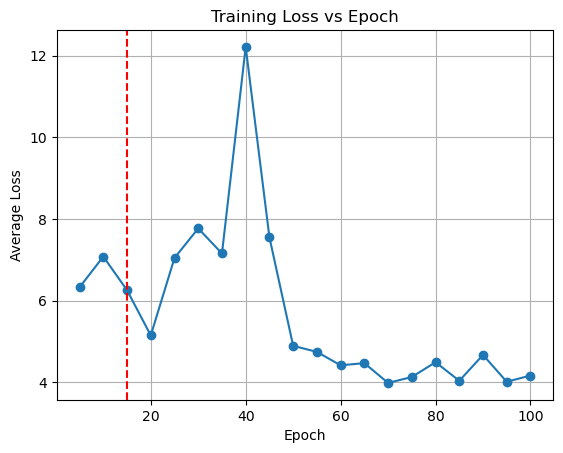

In [17]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("loss_curve.csv")

plt.plot(df["epoch"], df["avg_loss"], marker="o")
plt.xlabel("Epoch")
plt.ylabel("Average Loss")
plt.title("Training Loss vs Epoch")
plt.grid(True)
plt.axvline(x=15, color="red", linestyle="--", label="Greedy Search Start")

plt.show()

In [66]:
import torch
print(torch.cuda.memory_summary())

|===========================================================================|
|                  PyTorch CUDA memory summary, device ID 0                 |
|---------------------------------------------------------------------------|
|            CUDA OOMs: 2            |        cudaMalloc retries: 2         |
|===========================================================================|
|        Metric         | Cur Usage  | Peak Usage | Tot Alloc  | Tot Freed  |
|---------------------------------------------------------------------------|
| Allocated memory      |  22705 MiB |  22705 MiB |  25991 MiB |   3286 MiB |
|       from large pool |  22627 MiB |  22627 MiB |  25476 MiB |   2849 MiB |
|       from small pool |     78 MiB |     81 MiB |    514 MiB |    436 MiB |
|---------------------------------------------------------------------------|
| Active memory         |  22705 MiB |  22705 MiB |  25991 MiB |   3286 MiB |
|       from large pool |  22627 MiB |  22627 MiB |  25476 MiB |

In [58]:
import torch
torch.cuda.empty_cache()

In [ ]:
# old LR scheduler
optimizer = optim.SGD(snet.parameters(), lr = 0.1, momentum=0.9, weight_decay=4e-5)
    scheduler_warmup = LinearLR(optimizer, start_factor=0.01, end_factor=1.0, total_iters=warmup_epochs)  # increases LR linearly, up to 0.1 as we warm up
    scheduler_cosine  = CosineAnnealingLR(optimizer, T_max=(epochs-warmup_epochs))  # decreases LR from 0.1 to 0 over remaining epochs
    scheduler = SequentialLR(
        optimizer, schedulers=[scheduler_warmup, scheduler_cosine], milestones=[warmup_epochs]  # scheduler puts these together
    )
    


In [19]:
!git status

On branch main
Your branch is up to date with 'origin/main'.

Changes not staged for commit:
  (use "git add <file>..." to update what will be committed)
  (use "git restore <file>..." to discard changes in working directory)
	modified:   knowledge_distillation/model_init.py
	modified:   knowledge_distillation/optimization.ipynb
	modified:   knowledge_distillation/train_loop.py
	modified:   radimage_data_download.ipynb
	modified:   radimage_model_download.ipynb

Untracked files:
  (use "git add <file>..." to include in what will be committed)
	final_student_v1_epoch_10.pth
	final_student_v1_epoch_20.pth
	final_student_v1_epoch_30.pth
	final_student_v1_epoch_40.pth
	final_student_v1_epoch_50.pth
	final_student_v2_epoch_10.pth
	final_student_v2_epoch_20.pth
	final_student_v2_epoch_30.pth
	final_student_v2_epoch_40.pth
	final_student_v2_epoch_50.pth
	hardware_lut.json
	knowledge_distillation/main.ipynb
	knowledge_distillation/supernet_v1_loss.csv
	loss_curve.csv
	supernet_epoch_10.pth
	su

In [23]:
!git add knowledge_distillation/main.ipynb optimization.ipynb

fatal: pathspec 'optimization.ipynb' did not match any files


In [ ]:
!git commit -m "NAS+KD progress"

In [ ]:
!git push origin main